EXPLORATION DES DONNÉES

Info - Dataset brut
Shape      : 4372 lignes x 52 colonnes
NaN total  : 1390
Doublons   : 0
Types      :
  int64        -> 20 colonnes
  str          -> 18 colonnes
  float64      -> 14 colonnes

Valeurs manquantes :
                         count  percent
Age                       1311    29.99
AvgDaysBetweenPurchases     79     1.81


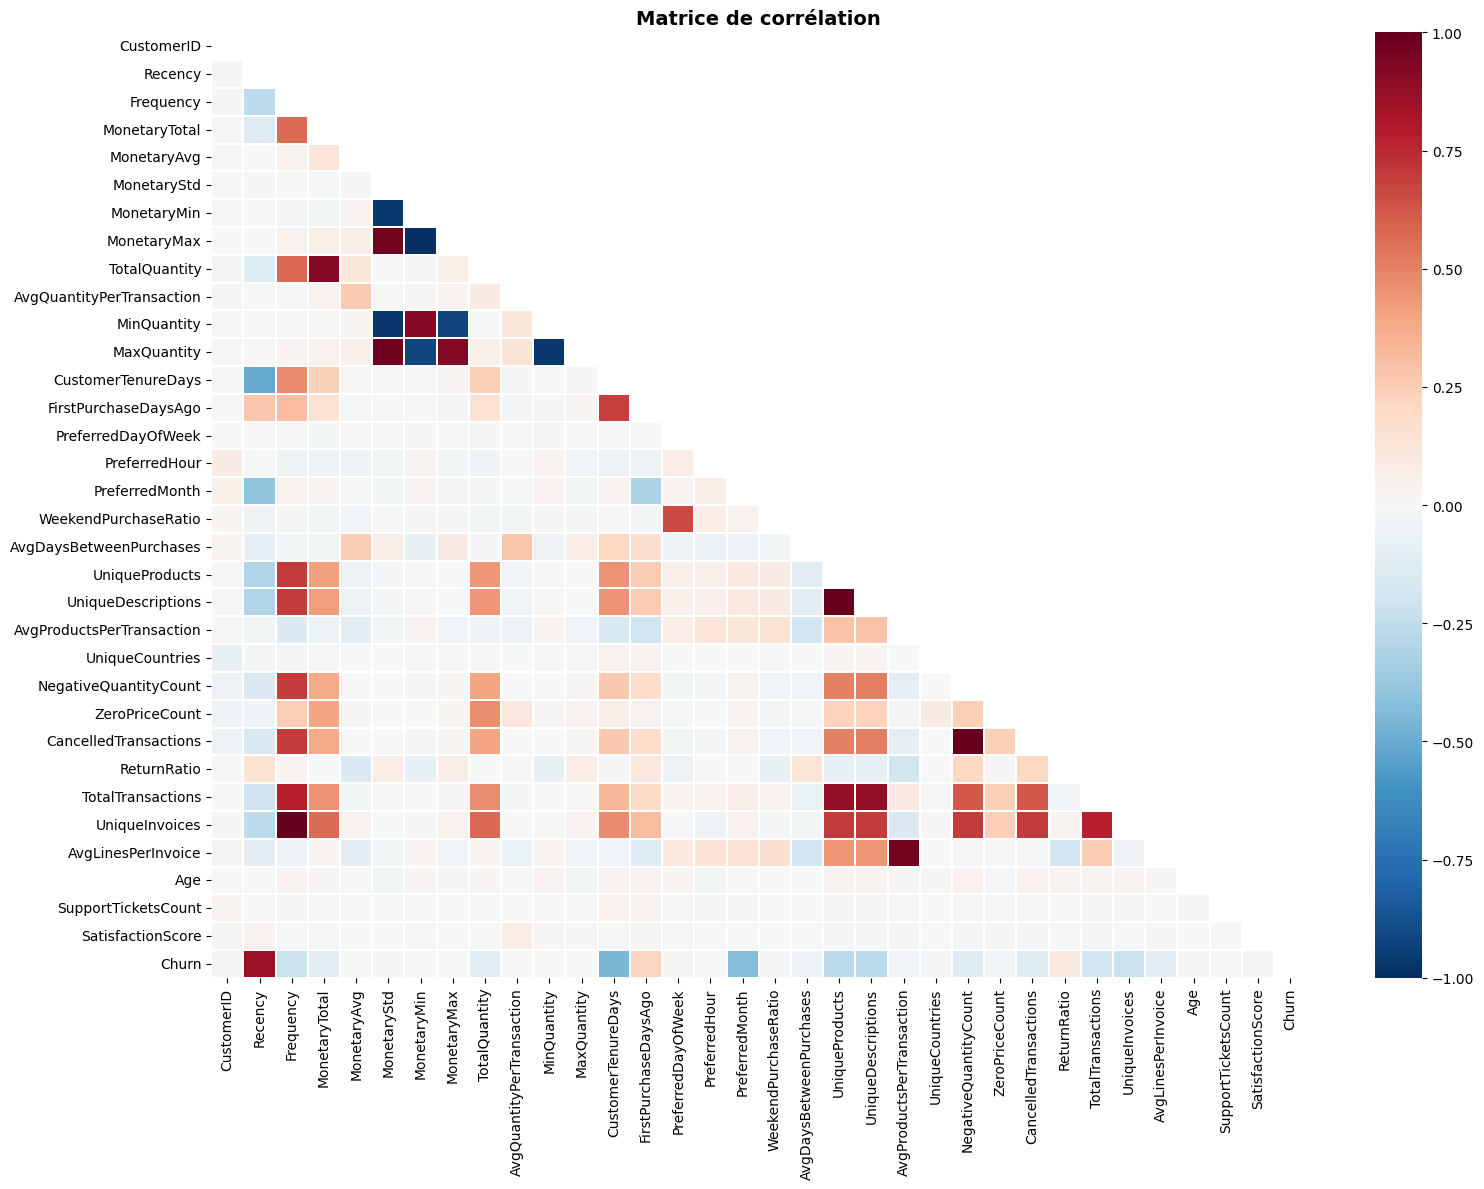


  Paires avec |corr| ≥ 0.8 :
    Frequency                           ↔ UniqueInvoices                      : +1.0000
    NegativeQuantityCount               ↔ CancelledTransactions               : +1.0000
    UniqueProducts                      ↔ UniqueDescriptions                  : +0.9999
    MonetaryMin                         ↔ MonetaryMax                         : -0.9939
    MonetaryStd                         ↔ MinQuantity                         : -0.9740
    MonetaryStd                         ↔ MaxQuantity                         : +0.9726
    MonetaryStd                         ↔ MonetaryMin                         : -0.9673
    MonetaryStd                         ↔ MonetaryMax                         : +0.9661
    AvgProductsPerTransaction           ↔ AvgLinesPerInvoice                  : +0.9632
    MinQuantity                         ↔ MaxQuantity                         : -0.9612
    MonetaryTotal                       ↔ TotalQuantity                       : +0.9216
  

In [5]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Fix import
BASE_DIR = os.path.abspath("..")
SRC_DIR = os.path.join(BASE_DIR, "src")

if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

from utils import print_df_info, missing_report, correlation_matrix

DATA_PATH = os.path.join(BASE_DIR, "data", "raw", "data.csv")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

os.makedirs(REPORTS_DIR, exist_ok=True)

print("="*50)
print("EXPLORATION DES DONNÉES")
print("="*50)

df = pd.read_csv(DATA_PATH)

print_df_info(df, "Dataset brut")

missing = missing_report(df)
print("\nValeurs manquantes :")
print(missing)

missing.to_csv(os.path.join(REPORTS_DIR, "missing_report.csv"))

correlation_matrix(df, target='Churn')

df['Churn'].value_counts().plot(kind='bar')
plt.title("Distribution Churn")
plt.savefig(os.path.join(REPORTS_DIR, "churn_distribution.png"))
plt.close()

print("\nExploration terminée → reports/")